# Library Imports
Print python / package info and import libraries

In [1]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam

import json
import datetime
import getpass

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Run config (edit before running)
run_config = {
    "run_id": "branch-name:commit-hash",
    "date_time": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "features_used": ["CDHI","CDNI","DHI","DNI","HOUR","TEMPERATURE"],
    "n_features": 6,
    "scaler": "MinMaxScaler",
    "use_pca": False,
    "pca_n_components": None,
    "learning_rate": globals().get("learning_rate", 0.0005),
    "optimizer": "Adam",
    "loss": "mae",
    "epochs": globals().get("setEpoch", 50),
    "batch_size": globals().get("batch_size", 32),
    "lstm_units": [50, 50],
    "seq_len": globals().get("seq_len", 24),
    "validation_split": 0.1,
    "random_seed": 42,
    "user": getpass.getuser(),
    "cwd": os.getcwd()
}

# Print only the key tuning params to keep output tidy
_tune_keys = ["features_used","n_features","learning_rate","optimizer","loss","epochs","batch_size","lstm_units","seq_len","validation_split","random_seed"]
print("Tuning / run config summary:")
print(json.dumps({k: run_config.get(k) for k in _tune_keys}, indent=2))

# Results record (fill after run)
results = {
    "run_id": run_config["run_id"],
    "training_time_s": None,
    "train_loss": None,
    "val_loss": None,
    "test_MAE": None,
    "test_MSE": None,
    "test_RMSE": None,
    "test_R2": None,
    "model_path": os.path.join(os.getcwd(), "Images", "model_run.h5"),
    "plot_path": os.path.join(os.getcwd(), "Images", "pred_plot.png"),
    "notes": ""
}

def save_run_record(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Results")
    os.makedirs(out_dir, exist_ok=True)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    path = os.path.join(out_dir, f"run_{ts}.json")
    with open(path, "w") as f:
        json.dump({"config": run_config, "results": results}, f, indent=2)
    print("Saved run record to", path)

# New: save a plain-text tuning summary into Images/
def save_tuning_summary(run_config, results, out_dir=None):
    out_dir = out_dir or os.path.join(os.getcwd(), "Images")
    os.makedirs(out_dir, exist_ok=True)
    # include microseconds and MAE for a unique, informative filename
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    mae = results.get("test_MAE")
    mae_tag = f"_mae{mae:.4f}" if mae is not None else ""
    path = os.path.join(out_dir, f"tuning_summary_{ts}{mae_tag}.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write("Run tuning summary\n")
        f.write("="*48 + "\n\n")
        f.write("Run config:\n")
        f.write(json.dumps(run_config, indent=2))
        f.write("\n\nResults:\n")
        f.write(json.dumps(results, indent=2))
        f.write("\n")
    print("Saved tuning summary to", path)
    return path

# Example usage (fill results then call save_run_record)
# results["training_time_s"] = 123.4
# results["test_MAE"] = mae_value
# save_run_record(run_config, results)

print('Python:', sys.version.splitlines()[0])
print('Executable:', sys.executable)
print('cwd:', os.getcwd())
print('Available CSVs:', glob.glob(os.path.join(os.getcwd(), '*.csv')))

import glob, os
print("Results:", glob.glob(os.path.join(os.getcwd(),"Results","run_*.json")))
print("Images:", glob.glob(os.path.join(os.getcwd(),"Images","*")))


Tuning / run config summary:
{
  "features_used": [
    "CDHI",
    "CDNI",
    "DHI",
    "DNI",
    "HOUR",
    "TEMPERATURE"
  ],
  "n_features": 6,
  "learning_rate": 0.0005,
  "optimizer": "Adam",
  "loss": "mae",
  "epochs": 50,
  "batch_size": 32,
  "lstm_units": [
    50,
    50
  ],
  "seq_len": 24,
  "validation_split": 0.1,
  "random_seed": 42
}
Python: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Executable: c:\Users\nnaji\AppData\Local\Programs\Python\Python313\python.exe
cwd: c:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files
Available CSVs: ['c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\BigData.csv', 'c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\MedData.csv', 'c:\\Users\\nnaji\\OneDrive\\Documents\\GitHub\\UGRA_LSTM_Solar-Prediction\\File Versions py files\\SmallData.csv']
Results: []
Image

## Parameters

In [2]:
learning_rate = 0.0005
setEpoch = 50
batch_size = 32

# explicit data folder and csv
data_dir = r"C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files"
csv_path = os.path.join(data_dir, 'BigData.csv')
assert os.path.isfile(csv_path), f"CSV not found: {csv_path}"
print('Loading dataset:', csv_path)


Loading dataset: C:\Users\nnaji\OneDrive\Documents\GitHub\UGRA_LSTM_Solar-Prediction\File Versions py files\BigData.csv


## Load data

In [3]:
df = pd.read_csv(csv_path)
df.head()

,MONTH,DAY,HOUR,MINUTE,TEMPERATURE,WINDANGLE,WINDSPEED,ZENITH,CDHI,CDNI,DHI,DNI,CLOUD,POWER
0,1,1,0,0,10.1,261,4.7,170.95,0,0,0,0,7,0.0
1,1,1,0,30,10.3,261,4.8,168.57,0,0,0,0,6,0.0
2,1,1,1,0,10.4,260,5.0,163.66,0,0,0,0,7,0.0
3,1,1,1,30,10.3,259,4.9,157.84,0,0,0,0,6,0.0
4,1,1,2,0,10.2,258,4.9,151.69,0,0,0,0,6,0.0


## Exploratory plots (compact)
Time-series overview, heatmap and boxplots; remove or reduce these later if too many features.

In [4]:
# # quick overview: small figure set
# # These plots give a quick visual overview of the features and their correlations. Currently Commented out. 
# df.plot(subplots=True, figsize=(12, 8), title='Feature Time Series')
# plt.tight_layout()
# #plt.show()

# plt.figure(figsize=(8,6))
# sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
# plt.title('Feature Correlation Heatmap')
# #plt.show()


## Preprocessing: separate target, reshape, normalize

PCA reduced shape: (17520, 9)
Explained variance ratio (per PC): [0.35782014 0.1031635  0.09104578 0.08173935 0.07775868 0.07691203
 0.06561879 0.05628561 0.04188624]
Cumulative explained variance: [0.35782014 0.46098364 0.55202942 0.63376876 0.71152745 0.78843948
 0.85405827 0.91034388 0.95223012]


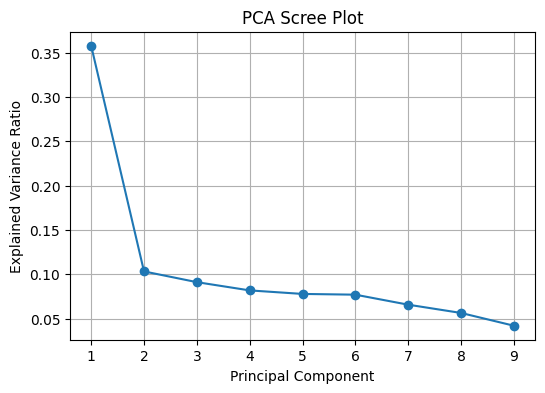

In [5]:
# PCA-based preprocessing
target_col = "POWER"

# select numeric features and separate target
numeric = df.select_dtypes(include=[np.number]).copy()
if target_col in numeric.columns:
    X = numeric.drop(columns=[target_col])
    y = numeric[target_col].copy()
else:
    X = numeric
    y = df[target_col] if target_col in df.columns else None

# standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: keep 95% variance (or use n_components=int(...) to fix number)
pca = PCA(n_components=0.95, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print("PCA reduced shape:", X_pca.shape)
print("Explained variance ratio (per PC):", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

# DataFrame of principal components (optional, easier to inspect)
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pc_cols, index=df.index)

# Replace feature matrix used downstream
solar_Xdata = pca_df.values            # shape (n_samples, n_components)
solar_ydata = y.values.reshape(-1, 1) if y is not None else None

# optional scree plot
    plt.figure(figsize=(6,4))
    plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, 'o-')
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance Ratio')
    plt.title('PCA Scree Plot')
    plt.grid(True)
    plt.show()


## Create sequences for LSTM
Using 24 time steps as in your .py file

In [6]:
# Multi-month experiment: Train on 11 months, test on 1 month (repeat for all 12 months)
# Streamlined version - MAE results only
import time
from datetime import datetime

# Initialize results storage
all_results = {}
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("="*60)
print("MULTI-MONTH EXPERIMENT: 12 separate train/test cycles")
print("Each month will be used as test set, other 11 as training")
print("="*60)

# First, create sequences once (same for all experiments)
seq_len = 24
X, y_seq = [], []
months = []

for i in range(seq_len, len(solar_ydata)):
    X.append(solar_Xdata[i-seq_len:i, :])
    y_seq.append(solar_ydata[i, 0])
    months.append(df.iloc[i]['MONTH'])

X = np.array(X)
y = np.array(y_seq)
months = np.array(months)

print(f'Total sequences created: {X.shape[0]}')

# Calculate monthly sample counts
print("\nMonthly sample distribution:")
for month in range(1, 13):
    count = np.sum(months == month)
    print(f'Month {month:2d} ({month_names[month-1]}): {count:4d} samples')

print(f"\nStarting 12-month experiment cycle (Epochs: {setEpoch})...")

# Run experiment for each month
for test_month in range(1, 13):
    print(f"\nExperiment {test_month}/12: Testing {month_names[test_month-1]}...", end=" ")
    
    start_time = time.time()
    
    # Split data for this month
    test_mask = (months == test_month)
    train_mask = ~test_mask
    
    X_train = X[train_mask]
    y_train = y[train_mask]
    X_test = X[test_mask]
    y_test = y[test_mask]
    
    # Check if we have enough test data
    if len(X_test) < 10:
        print(f"SKIPPED (only {len(X_test)} samples)")
        continue
    
    # Build fresh model for this experiment
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units=50))
    model.add(Dense(units=1))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_absolute_error')
    
    # Train model (silent)
    history = model.fit(X_train, y_train, epochs=setEpoch, batch_size=batch_size, 
                       validation_split=0.1, verbose=0)
    
    # Make predictions
    y_pred = model.predict(X_test, verbose=0)
    y_train_pred = model.predict(X_train, verbose=0)
    
    # Calculate metrics
    test_mae = mean_absolute_error(y_test, y_pred.flatten())
    train_mae = mean_absolute_error(y_train, y_train_pred.flatten())
    
    training_time = time.time() - start_time
    
    # Store results
    all_results[test_month] = {
        'month_name': month_names[test_month-1],
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'train_mae': float(train_mae),
        'test_mae': float(test_mae),
        'training_time': training_time
    }
    
    print(f"Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f} ({training_time:.1f}s)")
    
    # Clear memory
    del model
    import gc
    gc.collect()

print(f"\n" + "="*70)
print("EXPERIMENT RESULTS SUMMARY:")
print("="*70)
print(f"{'Month':<8} {'Train MAE':<12} {'Test MAE':<12} {'Ratio':<8} {'Samples':<10} {'Time(s)':<8}")
print("-" * 70)

# Sort results and display
mae_results = []
for month in range(1, 13):
    if month in all_results:
        r = all_results[month]
        ratio = r['test_mae'] / r['train_mae']
        mae_results.append((month, r['month_name'], r['train_mae'], r['test_mae'], ratio))
        print(f"{r['month_name']:<8} {r['train_mae']:<12.4f} {r['test_mae']:<12.4f} {ratio:<8.2f} {r['test_samples']:<10} {r['training_time']:<8.1f}")

# Find best and worst
mae_results.sort(key=lambda x: x[3])  # Sort by test MAE
best_month = mae_results[0]
worst_month = mae_results[-1]

print("=" * 70)
print(f"BEST PERFORMANCE:  {best_month[1]} (Test MAE: {best_month[3]:.4f})")
print(f"WORST PERFORMANCE: {worst_month[1]} (Test MAE: {worst_month[3]:.4f})")
print(f"AVERAGE TEST MAE:  {np.mean([r[3] for r in mae_results]):.4f}")

# Save results to simple CSV
import pandas as pd
results_df = pd.DataFrame([
    {'Month': r[1], 'Train_MAE': r[2], 'Test_MAE': r[3], 'Ratio': r[4]} 
    for r in mae_results
])

csv_path = os.path.join(os.getcwd(), 'monthly_mae_results.csv')
results_df.to_csv(csv_path, index=False)
print(f"\n✓ Results saved to: {csv_path}")

# Update main results
results["experiment_type"] = "12_month_mae_only"
results["best_month"] = best_month[1]
results["worst_month"] = worst_month[1] 
results["best_test_mae"] = best_month[3]
results["worst_test_mae"] = worst_month[3]
results["avg_test_mae"] = np.mean([r[3] for r in mae_results])

print(f"\nExperiment completed! Check {csv_path} for detailed results.")

MULTI-MONTH EXPERIMENT: 12 separate train/test cycles
Each month will be used as test set, other 11 as training
Total sequences created: 17496

Monthly sample distribution:
Month  1 (Jan): 1464 samples
Month  2 (Feb): 1344 samples
Month  3 (Mar): 1488 samples
Month  4 (Apr): 1440 samples
Month  5 (May): 1488 samples
Month  6 (Jun): 1440 samples
Month  7 (Jul): 1488 samples
Month  8 (Aug): 1488 samples
Month  9 (Sep): 1440 samples
Month 10 (Oct): 1488 samples
Month 11 (Nov): 1440 samples
Month 12 (Dec): 1488 samples

Starting 12-month experiment cycle (Epochs: 50)...

Experiment 1/12: Testing Jan... 

c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train MAE: 2.7772, Test MAE: 4.6422 (279.9s)

Experiment 2/12: Testing Feb... 

c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train MAE: 2.7255, Test MAE: 4.6003 (324.5s)

Experiment 3/12: Testing Mar... 

...

Train MAE: 2.6659, Test MAE: 4.2682 (301.9s)

Experiment 11/12: Testing Nov... 

c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train MAE: 2.6271, Test MAE: 3.9404 (298.9s)

Experiment 12/12: Testing Dec... 

c:\Users\nnaji\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train MAE: 2.7081, Test MAE: 4.6535 (290.4s)

EXPERIMENT RESULTS SUMMARY:
Month    Train MAE    Test MAE     Ratio    Samples    Time(s) 
----------------------------------------------------------------------
Jan      2.7772       4.6422       1.67     1464       279.9   
Feb      2.7255       4.6003       1.69     1344       324.5   
Mar      2.5280       5.7927       2.29     1488       289.1   
Apr      2.7670       3.9566       1.43     1440       309.1   
May      2.5657       3.9624       1.54     1488       292.8   
Jun      2.6041       3.5377       1.36     1440       311.2   
Jul      2.5223       4.3111       1.71     1488       285.5   
Aug      2.5703       5.9284       2.31     1488       285.3   
Sep      2.6252       3.5216       1.34     1440       287.6   
Oct      2.6659       4.2682       1.60     1488       301.9   
Nov      2.6271       3.9404       1.50     1440       298.9   
Dec      2.7081       4.6535       1.72     1488       290.4   
BEST PERFORMANCE:  Sep 